# Plume residence at FL430 (162.4 hPa), January releases, 2015–2025

Question: if a plume is released at FL430 on a January day at latitude φ₀, how often does it stay in the
stratosphere for the following 3–4 weeks? Proxy: the release isentrope must stay clear of the tropopause
wherever the plume can travel.

**Inputs**
- Dynamical (3.5 PVU / 380 K) tropopause from the Jülich ERA5 tropopause repository (`era5low`, 1°, 6-hourly):
  `dyn_p`, `dyn_t` → θ_trop = T (1000/p)^0.2857. Stored as daily mean and daily max.
- ERA5 temperature at 150 and 175 hPa from the public ARCO-ERA5 zarr on Google Cloud, interpolated in ln p
  to 162.4 hPa → θ_rel.

**Method 1 (conservative).** A release at (day d, longitude λ, latitude φ₀) is *resident* if
θ_rel(d, φ₀, λ) − Δ exceeds the **maximum** of the daily-max θ_trop over the box
|φ − φ₀| ≤ reach, all longitudes, days d … d+W−1.
Sensitivities: Δ ∈ {30, 40, 50} K, reach ∈ {10, 20, 30}°, W ∈ {21, 28} days.
Backstop: θ_rel > 380 K + Δ (overworld; no transport assumption).

**Method 2 (Gaussian spread).** Exposure fraction f = weighted fraction of plume-days within Δ of the
tropopause, with a Gaussian latitude weight of σ(t) = √(σ₀² + 2Kt) centred on φ₀, uniform in longitude,
equal weight per day, using daily-mean θ_trop. A release is resident if f < 5 %.
Sensitivities: K ∈ {1, 3, 10} × 10⁵ m² s⁻¹, Δ and W as above. Also reports the mean of f.

Releases are counted over all January days × all longitudes (360 per day). Tropopause data are extracted
for 1 Jan – 28 Feb so that 28-day windows starting on 31 Jan are complete. The tropopause domain is
extended to 10°S so that the reach = 30° box from a 40°S release is inside it.

**Stages**: 1 tropopause extraction · 2 ERA5 θ_rel · 3 method 1 · 4 method 2 · 5 plots.
Stages 1 and 2 are resumable (per-day and per-year files).

In [1]:
import glob
import os
import tempfile
import time
import urllib.error
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

# ---- configuration ----
BASE_URL = "https://datapub.fz-juelich.de/slcs/tropopause/data/v2/era5low"
ARCO_ERA5 = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
YEARS = (2015, 2025)               # inclusive
RELEASE_MONTH = 1                  # releases on January days
EXTRACT_END = (2, 28)              # extract tropopause data through 28 Feb (covers 31 Jan + 28 days)
LAT_MAX = -10.0                    # tropopause domain: lat <= -10
RELEASE_LATS = [-40, -45, -50, -55, -60, -65, -70]
ERA5_HOURS = [0, 6, 12, 18]        # hours used for the daily-mean theta_rel (set [12] to read 4x less data)

P_FL430 = 226.32 * np.exp(-9.80665 * (43000 * 0.3048 - 11000.0) / (287.05287 * 216.65))   # 162.4 hPa
KAPPA = 0.2857

DELTAS = [30.0, 40.0, 50.0]        # K
REACHES = [10, 20, 30]             # degrees latitude (method 1)
WINDOWS = [21, 28]                 # days
KS = [1e5, 3e5, 1e6]               # m2 s-1 (method 2)
SIGMA0_DEG = 1.0                   # initial spread floor for method 2
F_CRIT = 0.05                      # method 2 residence tolerance
THETA_OVERWORLD = 380.0            # K, backstop threshold before adding Delta

TROP_DIR = "trop_daily"            # stage 1 output, one file per day
REL_DIR = "theta_rel"              # stage 2 output, one file per year
RESULTS_FILE = "plume_residence_Jan_results.nc"
WORKERS = 4
for d_ in (TROP_DIR, REL_DIR):
    os.makedirs(d_, exist_ok=True)
print(f"FL430 = {P_FL430:.2f} hPa")

FL430 = 162.36 hPa


## Stage 1: tropopause extraction (Jülich)

For each day from 1 Jan to 28 Feb, 2015–2025: download, keep `dyn_z`, `dyn_p`, `dyn_t` at lat ≤ −10°,
drop the duplicate `lon = 180` column, compute θ_trop at each 6-hourly step, and store the daily mean of
z, p, t and θ_trop plus the daily max of θ_trop. Downloads run in threads; netCDF I/O stays in the main
thread (HDF5 is not thread-safe). Re-running skips days already on disk.

In [2]:
def extract_days():
    for y in range(YEARS[0], YEARS[1] + 1):
        d, end = date(y, 1, 1), date(y, *EXTRACT_END)
        while d <= end:
            yield d
            d += timedelta(days=1)


def url_for(d):
    return f"{BASE_URL}/{d.year}/era5low_{d.year}_{d.month:02d}_{d.day:02d}.nc"


def trop_path(d):
    return os.path.join(TROP_DIR, f"trop_{d.isoformat()}.nc")


def download(d, tmpdir, retries=4):
    dest = os.path.join(tmpdir, f"{d.isoformat()}.nc")
    err = None
    for k in range(retries):
        try:
            with urllib.request.urlopen(url_for(d), timeout=180) as r, open(dest, "wb") as f:
                while chunk := r.read(1 << 20):
                    f.write(chunk)
            return d, dest, "ok"
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return d, None, "missing"
            err = e
        except Exception as e:  # noqa: BLE001
            err = e
        time.sleep(2 ** k)
    if os.path.exists(dest):
        os.remove(dest)
    return d, None, f"failed: {err}"


def reduce_and_write(d, path):
    with xr.open_dataset(path) as ds:
        sub = ds[["dyn_z", "dyn_p", "dyn_t"]].sel(lat=slice(-90, LAT_MAX), lon=slice(-180, 179.5)).load()
    assert sub.dyn_z.attrs.get("units") == "km", sub.dyn_z.attrs
    assert sub.dyn_p.attrs.get("units", "hPa").lower() in ("hpa", "mb"), sub.dyn_p.attrs
    assert sub.dyn_t.attrs.get("units", "K") == "K", sub.dyn_t.attrs
    theta = sub.dyn_t * (1000.0 / sub.dyn_p) ** KAPPA
    t0 = np.datetime64(d.isoformat(), "ns")
    out = xr.Dataset(dict(
        z=sub.dyn_z.mean("time", skipna=True).astype("f4"),
        p=sub.dyn_p.mean("time", skipna=True).astype("f4"),
        t=sub.dyn_t.mean("time", skipna=True).astype("f4"),
        theta_mean=theta.mean("time", skipna=True).astype("f4"),
        theta_max=theta.max("time", skipna=True).astype("f4"),
        nvalid=sub.dyn_z.notnull().sum("time").astype("int8"),
    )).expand_dims(time=[t0])
    out.z.attrs, out.p.attrs, out.t.attrs = dict(units="km"), dict(units="hPa"), dict(units="K")
    out.theta_mean.attrs = dict(units="K", long_name="daily mean of 6-hourly theta at the dynamical tropopause")
    out.theta_max.attrs = dict(units="K", long_name="daily max of 6-hourly theta at the dynamical tropopause")
    tmp = trop_path(d) + ".part"
    out.to_netcdf(tmp)
    os.replace(tmp, trop_path(d))


days = list(extract_days())
todo = [d for d in days if not os.path.exists(trop_path(d))]
print(f"{len(days)} days; {len(todo)} to extract")

missing, failed = [], []
tmpdir = tempfile.mkdtemp(prefix="trop_")
t_start = time.time()
with ThreadPoolExecutor(WORKERS) as pool:
    futs = [pool.submit(download, d, tmpdir) for d in todo]
    for i, fu in enumerate(as_completed(futs), 1):
        d, path, status = fu.result()
        if status == "missing":
            missing.append(d)
        elif status != "ok":
            failed.append((d, status))
        else:
            try:
                reduce_and_write(d, path)
            except Exception as e:  # noqa: BLE001
                failed.append((d, f"reduce: {e}"))
            finally:
                os.remove(path)
        if i % 50 == 0 or i == len(todo):
            print(f"  {i}/{len(todo)}  {time.time() - t_start:.0f} s  missing={len(missing)} failed={len(failed)}")
print("missing (404):", sorted(missing))
print("failed:", sorted(failed))

649 days; 0 to extract
missing (404): []
failed: []


## Stage 2: θ at FL430 from ARCO-ERA5

Reads ERA5 temperature at 150 and 175 hPa for the January days of each year at `ERA5_HOURS`, selects the
1° points of the Jülich grid (the 0.25° grid contains them exactly), interpolates in ln p to 162.4 hPa,
converts to θ, and stores the daily mean per year. Needs `gcsfs` and `zarr` (`pip install gcsfs zarr`).

Not yet verified: the exact store path/variable names and how far the store extends in time. The cell
prints the time range first; if a January is beyond the end of the store, that year is reported and skipped.

In [3]:
def rel_path(y):
    return os.path.join(REL_DIR, f"theta_rel_{y}.nc")


def release_days(y):
    return pd.date_range(f"{y}-{RELEASE_MONTH:02d}-01", periods=31, freq="D").to_pydatetime()


need = [y for y in range(YEARS[0], YEARS[1] + 1) if not os.path.exists(rel_path(y))]
print("years to fetch:", need)

if need:
    era = xr.open_zarr(ARCO_ERA5, chunks=None, storage_options=dict(token="anon"))
    print(era["temperature"].dims, "time range:", str(era.time.values[0])[:10], "..", str(era.time.values[-1])[:10])
    lat_j = np.arange(-90.0, LAT_MAX + 0.5, 1.0)
    lon_j = np.arange(-180.0, 180.0, 1.0)
    lon_e = lon_j % 360.0                       # ARCO longitudes run 0..359.75
    w150 = (np.log(P_FL430) - np.log(150.0)) / (np.log(175.0) - np.log(150.0))   # weight of the 175 hPa level
    for y in need:
        times = np.array([np.datetime64(d.replace(hour=h)) for d in release_days(y) for h in ERA5_HOURS])
        if times[-1] > era.time.values[-1]:
            print(f"  {y}: beyond end of store, skipped")
            continue
        t0 = time.time()
        T = (era["temperature"].sel(time=times, level=[150, 175])
             .sel(latitude=lat_j, longitude=lon_e, method="nearest").load())
        T = T.assign_coords(longitude=lon_j).rename(latitude="lat", longitude="lon")
        T162 = (1 - w150) * T.sel(level=150) + w150 * T.sel(level=175)
        theta = (T162 * (1000.0 / P_FL430) ** KAPPA).drop_vars("level", errors="ignore")
        daily = theta.groupby("time.date").mean("time")
        daily = daily.rename(date="time").assign_coords(time=pd.to_datetime(daily["date"].values)).astype("f4")
        daily.name = "theta_rel"
        daily.attrs = dict(units="K", long_name=f"potential temperature at {P_FL430:.1f} hPa (FL430), daily mean",
                           hours=str(ERA5_HOURS), source=ARCO_ERA5)
        daily.to_dataset().to_netcdf(rel_path(y))
        print(f"  {y}: {daily.sizes['time']} days, theta_rel range {float(daily.min()):.0f}-{float(daily.max()):.0f} K, "
              f"{time.time() - t0:.0f} s")

theta_rel = xr.concat([xr.load_dataset(f).theta_rel for f in sorted(glob.glob(os.path.join(REL_DIR, '*.nc')))], "time")
print(theta_rel.sizes)

years to fetch: []


Frozen({'time': 341, 'lat': 81, 'lon': 360})


## Load the extracted tropopause fields

Per year: 59 days × lat × lon of θ_trop daily mean and daily max. Coverage is checked; a missing day
inside a window makes that window incomplete, so the number of missing days is reported.

In [4]:
trop = xr.concat([xr.load_dataset(f) for f in sorted(glob.glob(os.path.join(TROP_DIR, "trop_*.nc")))],
                 "time").sortby("time")
lat_t = trop.lat.values
print(trop.sizes)
per_year = trop.time.to_series().groupby(trop.time.dt.year.values).size()
print("days per year (expect 59):", per_year.to_dict())
print("fraction of grid points without tropopause (daily mean):", float(trop.theta_mean.isnull().mean()))
print(f"theta_trop zonal mean at release latitudes (Jan, K):")
jan = trop.theta_mean.where(trop.time.dt.month == RELEASE_MONTH, drop=True)
for phi in RELEASE_LATS:
    print(f"  {phi:4d}: {float(jan.sel(lat=phi).mean()):.1f}")
print("theta_rel zonal mean at release latitudes (Jan, K):")
for phi in RELEASE_LATS:
    print(f"  {phi:4d}: {float(theta_rel.sel(lat=phi).mean()):.1f}")


def year_block(y):
    """(trop for 1 Jan-28 Feb of year y, theta_rel for Jan days of year y)."""
    tr = trop.sel(time=str(y))
    rel = theta_rel.sel(time=str(y))
    idx = np.searchsorted(tr.time.values, rel.time.values)       # index of each release day in tr
    assert np.array_equal(tr.time.values[idx], rel.time.values), f"{y}: release days not all in tropopause series"
    return tr, rel, idx

Frozen({'time': 649, 'lat': 81, 'lon': 360})
days per year (expect 59): {2015: 59, 2016: 59, 2017: 59, 2018: 59, 2019: 59, 2020: 59, 2021: 59, 2022: 59, 2023: 59, 2024: 59, 2025: 59}
fraction of grid points without tropopause (daily mean): 5.389741736257744e-06
theta_trop zonal mean at release latitudes (Jan, K):


   -40: 348.3
   -45: 340.1
   -50: 331.2
   -55: 323.5
   -60: 318.3
   -65: 315.4
   -70: 313.6
theta_rel zonal mean at release latitudes (Jan, K):
   -40: 360.4
   -45: 364.5
   -50: 370.3
   -55: 375.8
   -60: 379.6
   -65: 381.3
   -70: 381.6


## Stage 3: method 1 (any exceedance in the box)

For each (φ₀, reach, W): the box maximum of daily-max θ_trop, M(d) = max over |φ − φ₀| ≤ reach, all
longitudes, days d … d+W−1. Resident if θ_rel(d, φ₀, λ) − Δ > M(d). Counts pooled over years, January
days and longitudes. Windows that run past the extracted data are dropped (none should, with data to 28 Feb).

In [5]:
yrs = sorted(set(theta_rel.time.dt.year.values) & set(trop.time.dt.year.values))
m1 = xr.DataArray(np.nan, dims=("lat0", "reach", "window", "delta"),
                  coords=dict(lat0=RELEASE_LATS, reach=REACHES, window=WINDOWS, delta=DELTAS), name="frac_resident_m1")
m1n = m1.copy().rename("n_releases")
backstop = xr.DataArray(np.nan, dims=("lat0", "delta"), coords=dict(lat0=RELEASE_LATS, delta=DELTAS),
                        name="frac_overworld")

for phi0 in RELEASE_LATS:
    hits = np.zeros((len(REACHES), len(WINDOWS), len(DELTAS)))
    n = np.zeros_like(hits)
    hits_b = np.zeros(len(DELTAS))
    n_b = 0
    for y in yrs:
        tr, rel, idx = year_block(y)
        r0 = rel.sel(lat=phi0).values                              # (nday_rel, nlon)
        for k, dl in enumerate(DELTAS):
            hits_b[k] += np.nansum(r0 > THETA_OVERWORLD + dl)
        n_b += np.isfinite(r0).sum()
        for i, R in enumerate(REACHES):
            band = tr.theta_max.sel(lat=slice(phi0 - R, phi0 + R))
            bm = band.max(("lat", "lon"), skipna=True).values        # (ntime,)
            for j, W in enumerate(WINDOWS):
                wm = sliding_window_view(bm, W).max(axis=1)         # M for start days 0..ntime-W
                ok = idx < wm.size                                    # windows fully inside the data
                M = wm[idx[ok]][:, None]                              # (nday_ok, 1)
                r = r0[ok]
                valid = np.isfinite(r) & np.isfinite(M)
                for k, dl in enumerate(DELTAS):
                    hits[i, j, k] += np.sum((r - dl > M) & valid)
                    n[i, j, k] += valid.sum()
    m1.loc[dict(lat0=phi0)] = hits / n
    m1n.loc[dict(lat0=phi0)] = n
    backstop.loc[dict(lat0=phi0)] = hits_b / n_b
    print(f"lat0={phi0}: n={int(n[0,0,0])} releases; resident (W=28, reach=20): "
          + ", ".join(f"D={dl:.0f}: {float(m1.sel(lat0=phi0, reach=20, window=28, delta=dl)):.3f}" for dl in DELTAS)
          + f"; overworld(D=40): {float(backstop.sel(lat0=phi0, delta=40)):.3f}")

lat0=-40: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000
lat0=-45: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000


lat0=-50: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000
lat0=-55: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000


lat0=-60: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000
lat0=-65: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000


lat0=-70: n=122760 releases; resident (W=28, reach=20): D=30: 0.000, D=40: 0.000, D=50: 0.000; overworld(D=40): 0.000


## Stage 4: method 2 (Gaussian spread, exposure fraction)

E(φ, day, x) = fraction of longitudes where daily-mean θ_trop > x, tabulated on 1 K bins. For a release
(d, λ) the exposure is f = (1/W) Σₜ Σ_φ w(φ, t) E(φ, d+t, θ_rel(d, φ₀, λ) − Δ), with
w(φ, t) ∝ exp[−(φ − φ₀)² / 2σ(t)²], σ(t) = √(σ₀² + 2Kt), normalised over the domain (lat ≤ −10°;
the tail beyond the domain edges is dropped). Resident if f < F_CRIT.

In [6]:
BIN_EDGES = np.arange(250.0, 501.0, 1.0)     # thresholds x; E is evaluated at the nearest edge
DEG_M = 111.2e3


def exceedance_table(theta):
    """theta: (time, lat, lon) -> E (time, lat, nbin): fraction of valid longitudes with theta > edge."""
    v = theta.values
    valid = np.isfinite(v)
    nval = valid.sum(-1)
    E = np.empty(v.shape[:2] + (BIN_EDGES.size,), dtype="f4")
    for k, e in enumerate(BIN_EDGES):
        E[..., k] = np.where(nval > 0, ((v > e) & valid).sum(-1) / np.maximum(nval, 1), np.nan)
    return E


def weights(phi0, K, W):
    """(W, nlat) Gaussian latitude weights, each row normalised over the domain."""
    t = np.arange(W) * 86400.0
    sig = np.sqrt(SIGMA0_DEG ** 2 + 2 * K * t / DEG_M ** 2)         # degrees
    w = np.exp(-0.5 * ((lat_t[None, :] - phi0) / sig[:, None]) ** 2)
    return w / w.sum(1, keepdims=True)


m2_mean = xr.DataArray(np.nan, dims=("lat0", "K", "window", "delta"),
                       coords=dict(lat0=RELEASE_LATS, K=KS, window=WINDOWS, delta=DELTAS), name="mean_exposure_m2")
m2_frac = m2_mean.copy().rename("frac_resident_m2")

Etab = {y: exceedance_table(year_block(y)[0].theta_mean) for y in yrs}
print("exceedance tables built")

for phi0 in RELEASE_LATS:
    fsum = np.zeros((len(KS), len(WINDOWS), len(DELTAS)))
    fres = np.zeros_like(fsum)
    n = np.zeros_like(fsum)
    for y in yrs:
        tr, rel, idx = year_block(y)
        E = Etab[y]
        r0 = rel.sel(lat=phi0).values                                 # (nday, nlon)
        for j, W in enumerate(WINDOWS):
            ok = idx + W <= E.shape[0]
            ii = idx[ok]
            for a, K in enumerate(KS):
                w = weights(phi0, K, W)                                # (W, nlat)
                for k, dl in enumerate(DELTAS):
                    x = r0[ok] - dl
                    kk = np.clip(np.rint(x - BIN_EDGES[0]).astype(int), 0, BIN_EDGES.size - 1)   # (nday_ok, nlon)
                    f = np.zeros_like(x)
                    for t in range(W):
                        Et = E[ii + t]                                 # (nday_ok, nlat, nbin)
                        Ex = np.take_along_axis(Et[:, :, None, :], kk[:, None, :, None], axis=3)[..., 0]  # (nday, nlat, nlon)
                        f += np.einsum("l,dlm->dm", w[t], np.nan_to_num(Ex, nan=0.0))
                    f /= W
                    valid = np.isfinite(x)
                    fsum[a, j, k] += f[valid].sum()
                    fres[a, j, k] += (f[valid] < F_CRIT).sum()
                    n[a, j, k] += valid.sum()
    m2_mean.loc[dict(lat0=phi0)] = fsum / n
    m2_frac.loc[dict(lat0=phi0)] = fres / n
    print(f"lat0={phi0}: resident (W=28, K=3e5): "
          + ", ".join(f"D={dl:.0f}: {float(m2_frac.sel(lat0=phi0, K=3e5, window=28, delta=dl)):.3f}" for dl in DELTAS)
          + f"; mean f (D=40): {float(m2_mean.sel(lat0=phi0, K=3e5, window=28, delta=40)):.3f}")

res = xr.merge([m1, m1n, backstop, m2_mean, m2_frac])
res.attrs = dict(years=f"{yrs[0]}-{yrs[-1]}", release_month=RELEASE_MONTH, p_release_hPa=float(P_FL430),
                 F_CRIT=F_CRIT, sigma0_deg=SIGMA0_DEG, theta_overworld=THETA_OVERWORLD, era5_hours=str(ERA5_HOURS))
res.to_netcdf(RESULTS_FILE)
print("wrote", RESULTS_FILE)

exceedance tables built


lat0=-40: resident (W=28, K=3e5): D=30: 0.000, D=40: 0.000, D=50: 0.000; mean f (D=40): 0.943


lat0=-45: resident (W=28, K=3e5): D=30: 0.000, D=40: 0.000, D=50: 0.000; mean f (D=40): 0.809


lat0=-50: resident (W=28, K=3e5): D=30: 0.000, D=40: 0.000, D=50: 0.000; mean f (D=40): 0.541


lat0=-55: resident (W=28, K=3e5): D=30: 0.081, D=40: 0.000, D=50: 0.000; mean f (D=40): 0.266


lat0=-60: resident (W=28, K=3e5): D=30: 0.778, D=40: 0.159, D=50: 0.000; mean f (D=40): 0.105


lat0=-65: resident (W=28, K=3e5): D=30: 0.985, D=40: 0.778, D=50: 0.082; mean f (D=40): 0.040


lat0=-70: resident (W=28, K=3e5): D=30: 0.999, D=40: 0.955, D=50: 0.559; mean f (D=40): 0.016
wrote plume_residence_Jan_results.nc


## Stage 5: plots

Fraction of releases (January days × longitudes, 2015–2025) that remain resident, against release latitude.
Colour = Δ; line style = reach (method 1) or K (method 2); one panel per window. Grey dash-dot lines are
the overworld backstop (θ_rel > 380 K + Δ), which does not depend on reach or window.

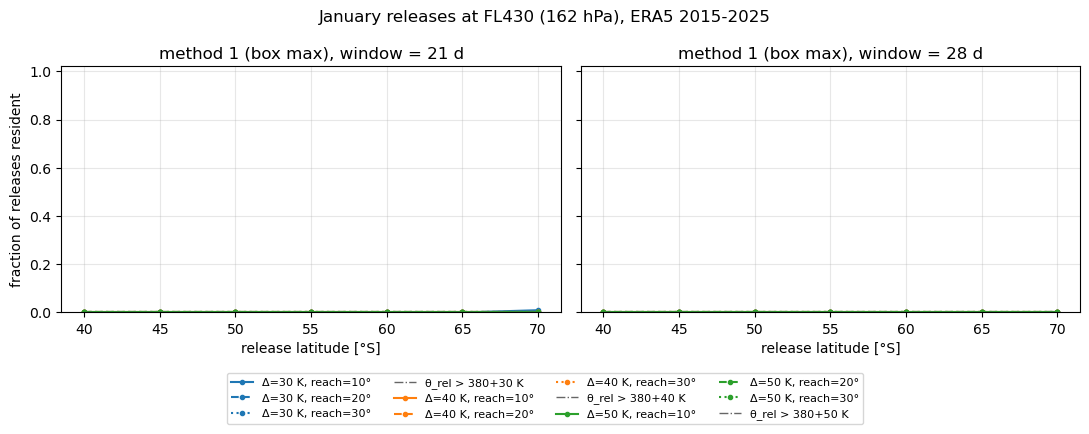

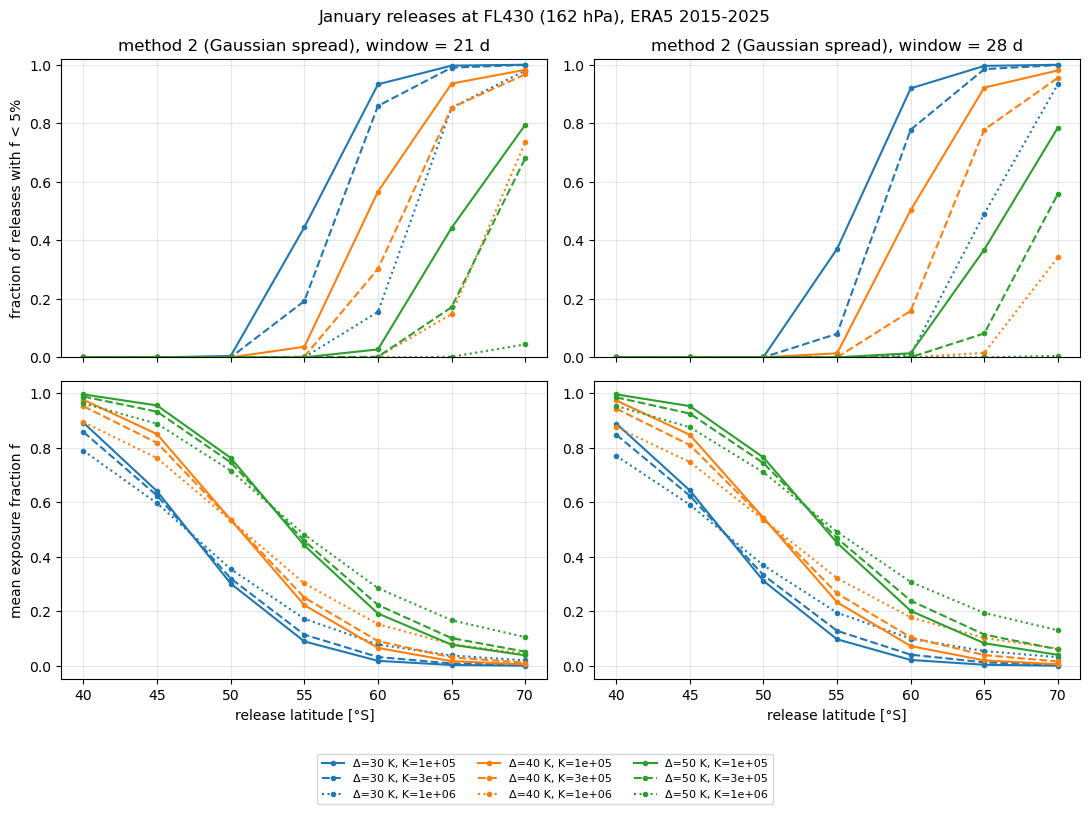

In [7]:
res = xr.open_dataset(RESULTS_FILE)
colors = dict(zip(DELTAS, ["tab:blue", "tab:orange", "tab:green"]))
x = [-v for v in RELEASE_LATS]

# --- method 1
styles = dict(zip(REACHES, ["-", "--", ":"]))
fig, axs = plt.subplots(1, len(WINDOWS), figsize=(11, 4.2), sharey=True)
for ax, W in zip(axs, WINDOWS):
    for dl in DELTAS:
        for R in REACHES:
            ax.plot(x, res.frac_resident_m1.sel(window=W, delta=dl, reach=R), color=colors[dl], ls=styles[R],
                    marker="o", ms=3, label=f"Δ={dl:.0f} K, reach={R}°")
        ax.plot(x, res.frac_overworld.sel(delta=dl), color="0.4", ls="-.", lw=1,
                label=f"θ_rel > 380+{dl:.0f} K")
    ax.set_title(f"method 1 (box max), window = {W} d")
    ax.set_xlabel("release latitude [°S]")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
axs[0].set_ylabel("fraction of releases resident")
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, fontsize=8, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"January releases at FL430 ({P_FL430:.0f} hPa), ERA5 {res.attrs['years']}")
fig.tight_layout(rect=(0, 0.12, 1, 1))
fig.savefig("residence_method1_Jan.pdf", bbox_inches="tight")
plt.show()

# --- method 2
styles = dict(zip(KS, ["-", "--", ":"]))
fig, axs = plt.subplots(2, len(WINDOWS), figsize=(11, 8), sharex=True)
for j, W in enumerate(WINDOWS):
    for dl in DELTAS:
        for K in KS:
            lab = f"Δ={dl:.0f} K, K={K:.0e}"
            axs[0, j].plot(x, res.frac_resident_m2.sel(window=W, delta=dl, K=K), color=colors[dl], ls=styles[K],
                           marker="o", ms=3, label=lab)
            axs[1, j].plot(x, res.mean_exposure_m2.sel(window=W, delta=dl, K=K), color=colors[dl], ls=styles[K],
                           marker="o", ms=3)
    axs[0, j].set_title(f"method 2 (Gaussian spread), window = {W} d")
    axs[0, j].set_ylim(0, 1.02)
    axs[1, j].set_xlabel("release latitude [°S]")
    for ax in axs[:, j]:
        ax.grid(alpha=0.3)
axs[0, 0].set_ylabel(f"fraction of releases with f < {F_CRIT:.0%}")
axs[1, 0].set_ylabel("mean exposure fraction f")
h, l = axs[0, 0].get_legend_handles_labels()
fig.legend(h, l, fontsize=8, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"January releases at FL430 ({P_FL430:.0f} hPa), ERA5 {res.attrs['years']}")
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig("residence_method2_Jan.pdf", bbox_inches="tight")
plt.show()